🌱 FIXED: Transfer Learning - Google Colab
 Plant Disease Detection with Memory Optimization
 For: 4GB GPU RAM + 8GB CPU RAM

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Option 1: Download kaggle.json from https://www.kaggle.com/settings/account
# Then upload it to Colab using the file upload panel

from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [3]:
# import os
# os.makedirs('~/.kaggle', exist_ok=True)
# for fn in uploaded.keys():
#     os.rename(fn, os.path.expanduser('~/.kaggle/kaggle.json'))

# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
# print("✅ Kaggle credentials configured!")

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
#give permission for access
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle credentials configured!")


✅ Kaggle credentials configured!


In [4]:
!pip install -q tensorflow keras numpy pandas pillow plotly scikit-learn

In [4]:
!pip install kaggle -q

# Download dataset from Kaggle
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

# Extract the dataset
!unzip -q -o plantvillage-dataset.zip

print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:16<00:00, 135MB/s]

✅ Dataset downloaded!


In [5]:

# Verify download
import os
dataset_path = '/content/plantvillage dataset/color'
if os.path.exists(dataset_path):
    num_images = sum([len(files) for r, d, files in os.walk(dataset_path)])
    num_classes = len(os.listdir(dataset_path))
    print(f"✅ Dataset downloaded successfully!")
    print(f"   Total images: {num_images}")
    print(f"   Number of classes: {num_classes}")
else:
    print("❌ Dataset not found. Check the path.")

✅ Dataset downloaded successfully!
   Total images: 54305
   Number of classes: 38


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


In [7]:
# FIX 1: Reduce batch size for 4GB GPU
BATCH_SIZE = 16  # CHANGED from 32 to 16 (important for 4GB GPU!)

# FIX 2: Reduce image size for faster processing
IMAGE_SIZE = 192  # CHANGED from 224 to 192 (less memory)

# FIX 3: Reduce epochs to prevent memory issues
EPOCHS_STAGE1 = 5  # CHANGED from 10 to 5
EPOCHS_STAGE2 = 5  # CHANGED from 10 to 5

# FIX 4: Aggressive memory management
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Reduce TF logging
tf.config.optimizer.set_jit(False)  # Disable JIT compilation

print(f"Configuration:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Image Size: {IMAGE_SIZE}")
print(f"  Stage 1 Epochs: {EPOCHS_STAGE1}")
print(f"  Stage 2 Epochs: {EPOCHS_STAGE2}")


Configuration:
  Batch Size: 16
  Image Size: 192
  Stage 1 Epochs: 5
  Stage 2 Epochs: 5


In [8]:
# Load data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,  # REDUCED from 20
    width_shift_range=0.15,  # REDUCED from 0.2
    height_shift_range=0.15,  # REDUCED from 0.2
    zoom_range=0.15,  # REDUCED from 0.2
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


In [9]:
# Test data - no augmentation, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
print("Loading training data...")
train_data = train_datagen.flow_from_directory(
    '/content/plantvillage dataset/color',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,  # Ensure shuffle
    seed=42
)

Loading training data...
Found 43456 images belonging to 38 classes.


In [11]:
print("Loading validation data...")
val_data = train_datagen.flow_from_directory(
    '/content/plantvillage dataset/color',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Loading validation data...
Found 10849 images belonging to 38 classes.


In [12]:
#summary
print(f"Data loaded!")
print(f"   Training samples: {train_data.samples}")
print(f"   Validation samples: {val_data.samples}")
print(f"   Number of classes: {train_data.num_classes}")
print(f"   Classes: {list(train_data.class_indices.keys())[:5]}...")

Data loaded!
   Training samples: 43456
   Validation samples: 10849
   Number of classes: 38
   Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...


In [13]:
print("\nBuilding model...")

# FIX: Use MobileNetV2 instead of EfficientNetB0
# MobileNetV2 is lighter and works better with 4GB GPU
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False


Building model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),  # REDUCED from 256
    layers.Dropout(0.3),  # INCREASED dropout for regularization
    layers.Dense(64, activation='relu'),   # REDUCED from 128
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,432,678 (9.28 MB)

 Trainable params: 174,694 (682.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [15]:
#compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # REDUCED from 1e-3
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")

✅ Model compiled!


`STAGE 1 - Train with Frozen Base`

In [16]:
# Stage 1: Frozen base
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


`Stage1: Training with frozen base`

In [17]:
print("\n" + "="*60)
print("STAGE 1: Training with FROZEN base model")
print("="*60)
print(f"Learning rate: 5e-4")
print(f"Epochs: {EPOCHS_STAGE1}")
print(f"Batch size: {BATCH_SIZE}")
print("="*60)


STAGE 1: Training with FROZEN base model
Learning rate: 5e-4
Epochs: 5
Batch size: 16


In [18]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_STAGE1,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,  # REDUCED from 3
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,  # REDUCED from 2
            min_lr=1e-5,
            verbose=1
        )
    ]
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2344s 860ms/step - accuracy: 0.6619 - loss: 1.1533 - val_accuracy: 0.8751 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2329s 857ms/step - accuracy: 0.7954 - loss: 0.6499 - val_accuracy: 0.8916 - val_loss: 0.3395 - learning_rate: 0.0010
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2317s 853ms/step - accuracy: 0.8216 - loss: 0.5701 - val_accuracy: 0.9013 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2290s 843ms/step - accuracy: 0.8361 - loss: 0.5233 - val_accuracy: 0.9100 - val_loss: 0.2748 - learning_rate: 0.0010
Epoch 5/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2296s 845ms/step - accuracy: 0.8449 - loss: 0.4962 - val_accuracy: 0.9196 - val_loss: 0.2620 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


In [19]:
print("\n✅ STAGE 1 Complete!")
print(f"Final training accuracy: {history1.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history1.history['val_accuracy'][-1]*100:.2f}%")


✅ STAGE 1 Complete!
Final training accuracy: 84.49%
Final validation accuracy: 91.96%


`Stage 2: Fine-tuning`

In [20]:
print("\n" + "="*60)
print("STAGE 2: Fine-tuning (UNFREEZING TOP LAYERS)")
print("="*60)


STAGE 2: Fine-tuning (UNFREEZING TOP LAYERS)


In [21]:
# Only unfreeze top 30% of layers
unfreeze_from = int(len(base_model.layers) * 0.7)
print(f"Unfreezing {len(base_model.layers) - unfreeze_from} layers...")
print(f"Keeping {unfreeze_from} layers frozen...")

base_model.trainable = True

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False

# Check which layers are trainable
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"✅ Trainable layers in base: {trainable_count}")

Unfreezing 47 layers...
Keeping 107 layers frozen...
✅ Trainable layers in base: 47


`Recompile for Stage 2`

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # MUCH LOWER learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model recompiled with lower learning rate (1e-4)")

✅ Model recompiled with lower learning rate (1e-4)


In [23]:
# STAGE 2 - Continue Training
print("\n" + "="*60)
print("STAGE 2: Continue training with fine-tuning")
print("="*60)
print(f"Learning rate: 1e-4 (VERY LOW for fine-tuning)")
print(f"Epochs: {EPOCHS_STAGE1} to {EPOCHS_STAGE1 + EPOCHS_STAGE2}")
print("="*60)


STAGE 2: Continue training with fine-tuning
Learning rate: 1e-4 (VERY LOW for fine-tuning)
Epochs: 5 to 10


In [24]:

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_STAGE1 + EPOCHS_STAGE2,
    initial_epoch=EPOCHS_STAGE1,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,
            min_lr=5e-5,
            verbose=1
        )
    ]
)

Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3243s 1s/step - accuracy: 0.8299 - loss: 0.5860 - val_accuracy: 0.9142 - val_loss: 0.2969 - learning_rate: 1.0000e-04
Epoch 7/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3252s 1s/step - accuracy: 0.8936 - loss: 0.3519 - val_accuracy: 0.9507 - val_loss: 0.1506 - learning_rate: 1.0000e-04
Epoch 8/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3220s 1s/step - accuracy: 0.9193 - loss: 0.2755 - val_accuracy: 0.9612 - val_loss: 0.1231 - learning_rate: 1.0000e-04
Epoch 9/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9324 - loss: 0.2277
Epoch 9: ReduceLROnPlateau reducing learning rate to 5e-05.
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3184s 1s/step - accuracy: 0.9341 - loss: 0.2211 - val_accuracy: 0.9615 - val_loss: 0.1268 - learning_rate: 1.0000e-04
Epoch 10/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3169s 1s/step - accuracy: 0.9520 - loss: 0.1565 - val_accuracy: 0.9798 - val_loss: 0.0652 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [25]:
print("\n✅ STAGE 2 Complete!")
print(f"Final training accuracy: {history2.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history2.history['val_accuracy'][-1]*100:.2f}%")



✅ STAGE 2 Complete!
Final training accuracy: 95.20%
Final validation accuracy: 97.98%


In [31]:
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)



FINAL EVALUATION


In [32]:
train_loss, train_acc = model.evaluate(train_data, verbose=0)
val_loss, val_acc = model.evaluate(val_data, verbose=0)

In [33]:
print(f"\n📊 FINAL RESULTS:")
print(f"   Training Accuracy:   {train_acc*100:.2f}%")
print(f"   Validation Accuracy: {val_acc*100:.2f}%")
print(f"   Training Loss:       {train_loss:.4f}")
print(f"   Validation Loss:     {val_loss:.4f}")


📊 FINAL RESULTS:
   Training Accuracy:   98.69%
   Validation Accuracy: 97.95%
   Training Loss:       0.0397
   Validation Loss:     0.0621


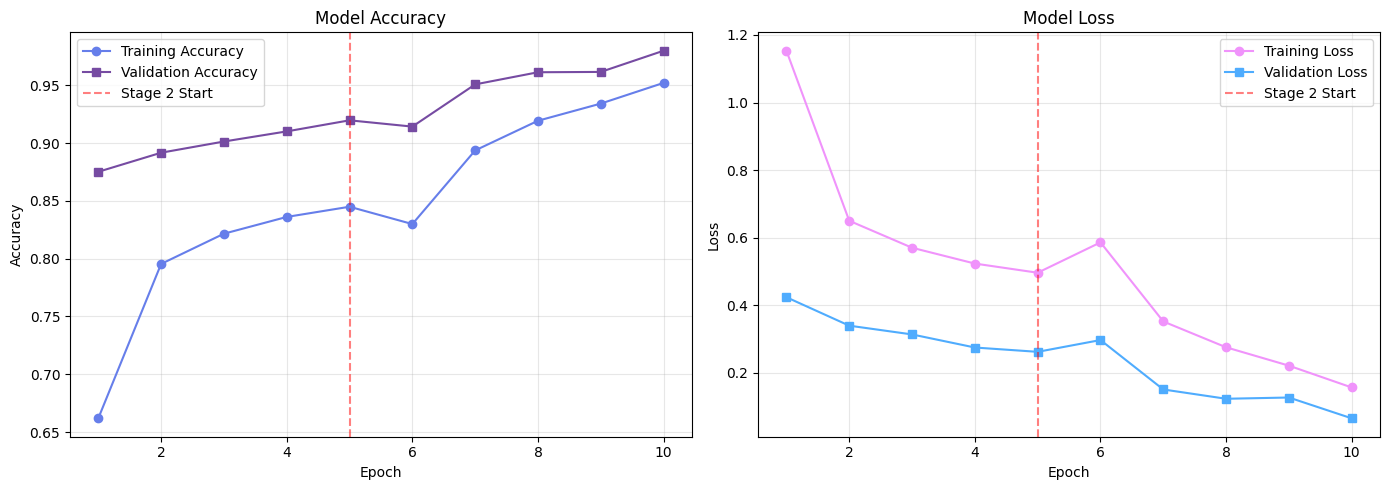

✅ Training history plot saved!


In [27]:
plt.figure(figsize=(14, 5))

# Combine histories
all_acc = history1.history['accuracy'] + history2.history['accuracy']
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss = history1.history['loss'] + history2.history['loss']
all_val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(all_acc) + 1)

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, all_acc, 'o-', label='Training Accuracy', color='#667eea')
plt.plot(epochs, all_val_acc, 's-', label='Validation Accuracy', color='#764ba2')
plt.axvline(x=EPOCHS_STAGE1, color='red', linestyle='--', alpha=0.5, label='Stage 2 Start')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, all_loss, 'o-', label='Training Loss', color='#f093fb')
plt.plot(epochs, all_val_loss, 's-', label='Validation Loss', color='#4facfe')
plt.axvline(x=EPOCHS_STAGE1, color='red', linestyle='--', alpha=0.5, label='Stage 2 Start')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Plant disease classification/training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Training history plot saved!")




In [28]:
#save model
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

# Save as .h5 (Keras format)
model_path = '/content/drive/MyDrive/Plant disease classification/plant_disease_model.h5'
model.save(model_path)
print(f"✅ Model saved to Google Drive: {model_path}")

# Also save locally
local_path = '/content/plant_disease_model.h5'
model.save(local_path)
print(f"✅ Model saved locally: {local_path}")

# Get file size
import os
file_size_mb = os.path.getsize(local_path) / (1024 * 1024)
print(f"   File size: {file_size_mb:.2f} MB")


SAVING MODEL


✅ Model saved to Google Drive: /content/drive/MyDrive/Plant disease classification/plant_disease_model.h5
✅ Model saved locally: /content/plant_disease_model.h5
   File size: 24.74 MB


In [29]:
#save class indicies
import json

# Save class indices for later use in Streamlit
class_indices = train_data.class_indices
class_indices_json = '/content/drive/MyDrive/Plant disease classification/class_indices.json'

with open(class_indices_json, 'w') as f:
    json.dump(class_indices, f, indent=2)

print(f"✅ Class indices saved: {class_indices_json}")
print(f"\n   Classes ({len(class_indices)}):")
for idx, (cls, num) in enumerate(list(class_indices.items())[:5]):
    print(f"      {num}: {cls}")
if len(class_indices) > 5:
    print(f"      ... and {len(class_indices) - 5} more classes")


✅ Class indices saved: /content/drive/MyDrive/Plant disease classification/class_indices.json

   Classes (38):
      0: Apple___Apple_scab
      1: Apple___Black_rot
      2: Apple___Cedar_apple_rust
      3: Apple___healthy
      4: Blueberry___healthy
      ... and 33 more classes


In [30]:
# CELL 19: Test Prediction
print("\n" + "="*60)
print("TEST PREDICTION")
print("="*60)

# Get one batch
test_images, test_labels = next(iter(val_data))

# Make prediction
predictions = model.predict(test_images[:5], verbose=0)

# Show predictions
for i in range(min(5, len(test_images))):
    pred_class_idx = np.argmax(predictions[i])
    pred_confidence = np.max(predictions[i])

    # Get actual class
    actual_class_idx = np.argmax(test_labels[i])

    # Reverse mapping
    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_class_name = idx_to_class[pred_class_idx]
    actual_class_name = idx_to_class[actual_class_idx]

    match = "✅" if pred_class_idx == actual_class_idx else "❌"

    print(f"\n{match} Sample {i+1}:")
    print(f"   Predicted: {pred_class_name} ({pred_confidence*100:.2f}%)")
    print(f"   Actual:    {actual_class_name}")

print("\n✅ Model training complete!")
print("=" * 60)


TEST PREDICTION

✅ Sample 1:
   Predicted: Apple___Apple_scab (99.99%)
   Actual:    Apple___Apple_scab

✅ Sample 2:
   Predicted: Apple___Apple_scab (100.00%)
   Actual:    Apple___Apple_scab

✅ Sample 3:
   Predicted: Apple___Apple_scab (99.99%)
   Actual:    Apple___Apple_scab

✅ Sample 4:
   Predicted: Apple___Apple_scab (94.12%)
   Actual:    Apple___Apple_scab

✅ Sample 5:
   Predicted: Apple___Apple_scab (99.53%)
   Actual:    Apple___Apple_scab

✅ Model training complete!


In [36]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image(model, class_indices, img_size=(224, 224)):

    # Upload image
    uploaded = files.upload()

    # Get file name
    img_path = list(uploaded.keys())[0]

    # Load image
    image = Image.open(img_path).convert("RGB")

    # Show image
    plt.imshow(image)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    # Preprocess image
    img = image.resize(img_size)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model.predict(img_array)

    pred_class_idx = np.argmax(predictions[0])
    pred_confidence = np.max(predictions[0])

    # Reverse mapping
    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_class_name = idx_to_class[pred_class_idx]

    # Output
    print("\n" + "="*50)
    print("PREDICTION RESULT")
    print("="*50)
    print(f"Predicted Class : {pred_class_name}")
    print(f"Confidence      : {pred_confidence*100:.2f}%")

Saving 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG to 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG


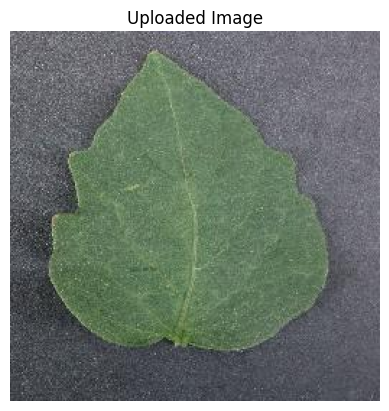

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

PREDICTION RESULT
Predicted Class : Tomato___healthy
Confidence      : 100.00%


In [38]:
predict_uploaded_image(model, class_indices)